In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
import jinja2
import time 

## **1.Выбор датасета**
### Я выбрал датасет по страховым расходам на человека. Выбран именно он, потому что немного фич, есть простор для feature engineering'a и размер датасета не особо большой (1300 строк)

In [22]:
df = pd.read_csv('data/insurance.csv')

## **2. EDA**

In [23]:
display(df.info())
display(df.describe())
display(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


None

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

*Nan'ов нет, заполнять ничего не надо. Разброс данных относительно небольшой.*

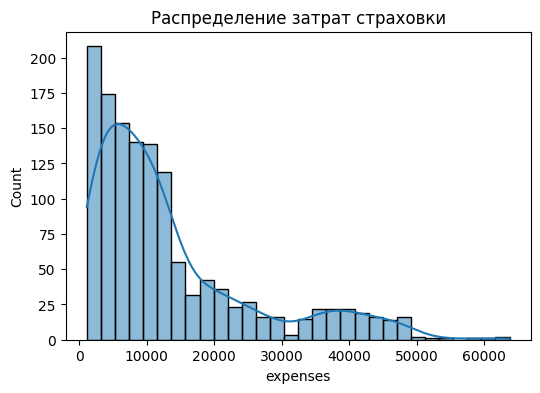

In [24]:
plt.figure(figsize=(6, 4))
sns.histplot(df['expenses'], kde=True, bins=30)
plt.title('Распределение затрат страховки')
plt.show()

*Затраты страховки - наша целовая переменная. видим два 'горба' (бимодальное распределение). Это может быть связанно с тем, что горб слева - это некурящие люди с хорошим здоровьем и ИМТ, а справа - курящие и/или имеющие проблемы со здоровьем или ИМТ.*

<Axes: xlabel='expenses', ylabel='Count'>

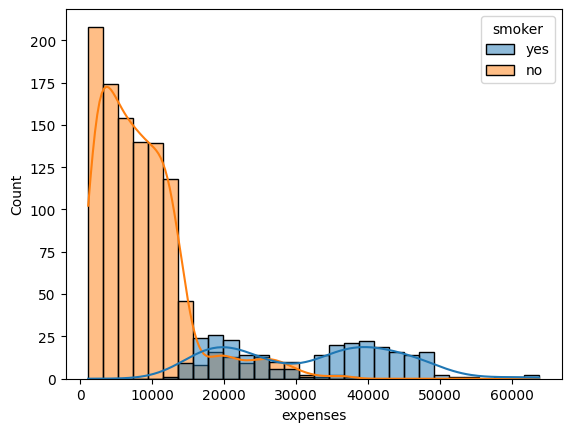

In [25]:
sns.histplot(data=df, x='expenses', hue='smoker', kde=True, bins=30)

*Подтверждаем нашу гипотезу вот таким графиком. Люди в левом горбе действительно не курят и меньше платят за страховку.*

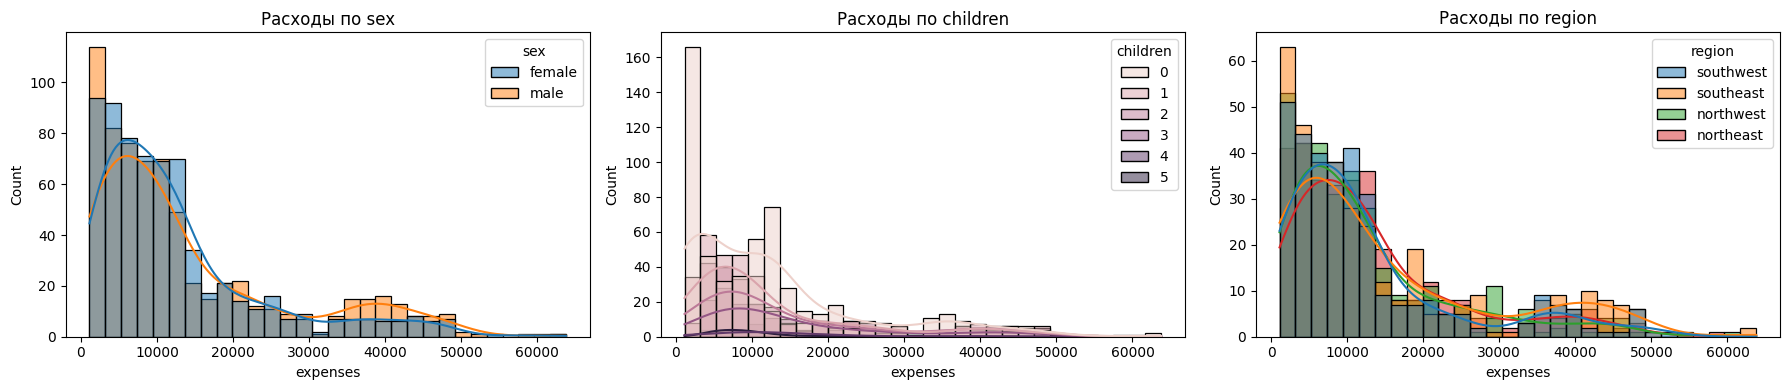

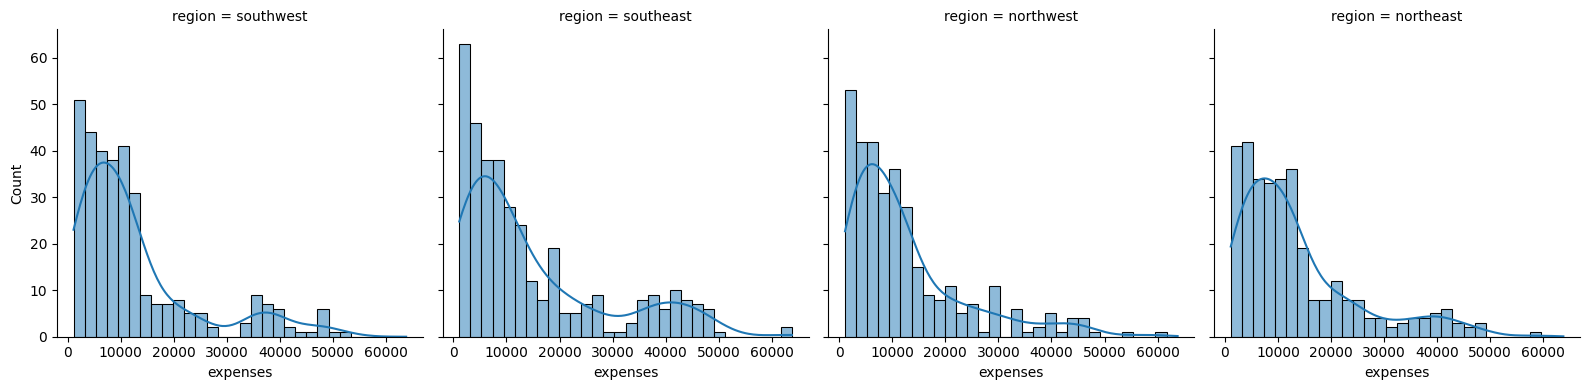

In [26]:
features = ['sex', 'children', 'region']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, col in enumerate(features):
    sns.histplot(data=df, x='expenses', hue=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Расходы по {col}')

plt.tight_layout()
plt.show()
sns.displot(data=df, x='expenses', col='region', kde=True, height=4, aspect=1)

*После интересного наблюдения с smokers хочется посмотреть и на другие графики. Я увидел, что expenses вообще не зависит от region, поэтому его можно смело удалить!*
***После теста я закомментил этот блок, потому что всё-таки regions немного поднял точность модели.***

*Nan'ов нет, заполнять ничего не надо. Разброс данных относительно небольшой.*

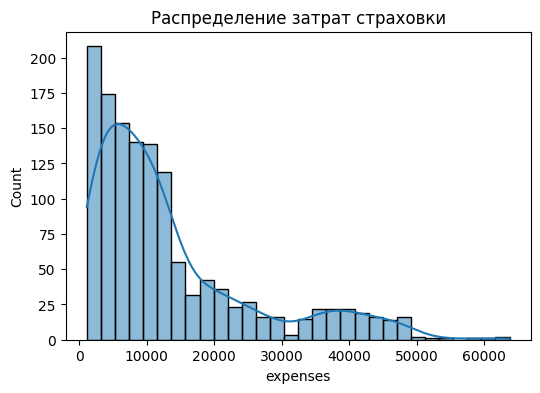

In [27]:
plt.figure(figsize=(6, 4))
sns.histplot(df['expenses'], kde=True, bins=30)
plt.title('Распределение затрат страховки')
plt.show()

*Затраты страховки - наша целовая переменная. видим два 'горба' (бимодальное распределение). Это может быть связанно с тем, что горб слева - это некурящие люди с хорошим здоровьем и ИМТ, а справа - курящие и/или имеющие проблемы со здоровьем или ИМТ.*

<Axes: xlabel='expenses', ylabel='Count'>

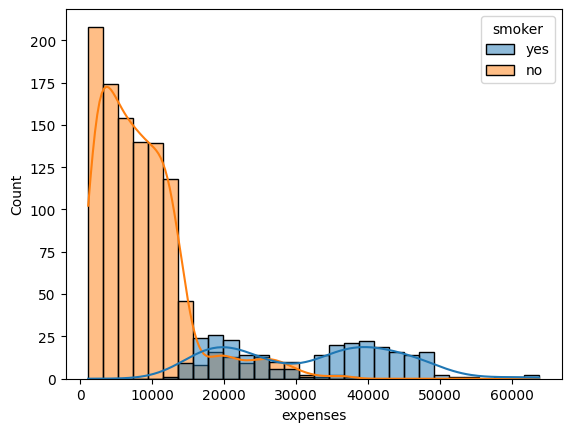

In [28]:
sns.histplot(data=df, x='expenses', hue='smoker', kde=True, bins=30)

*Подтверждаем нашу гипотезу вот таким графиком. Люди в левом горбе действительно не курят и меньше платят за страховку.*

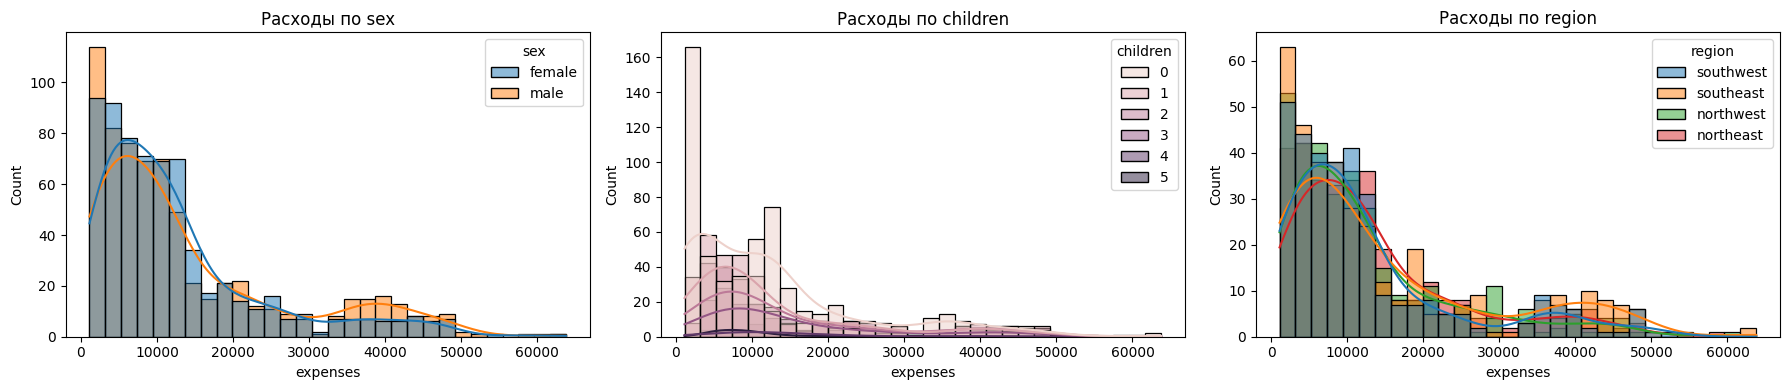

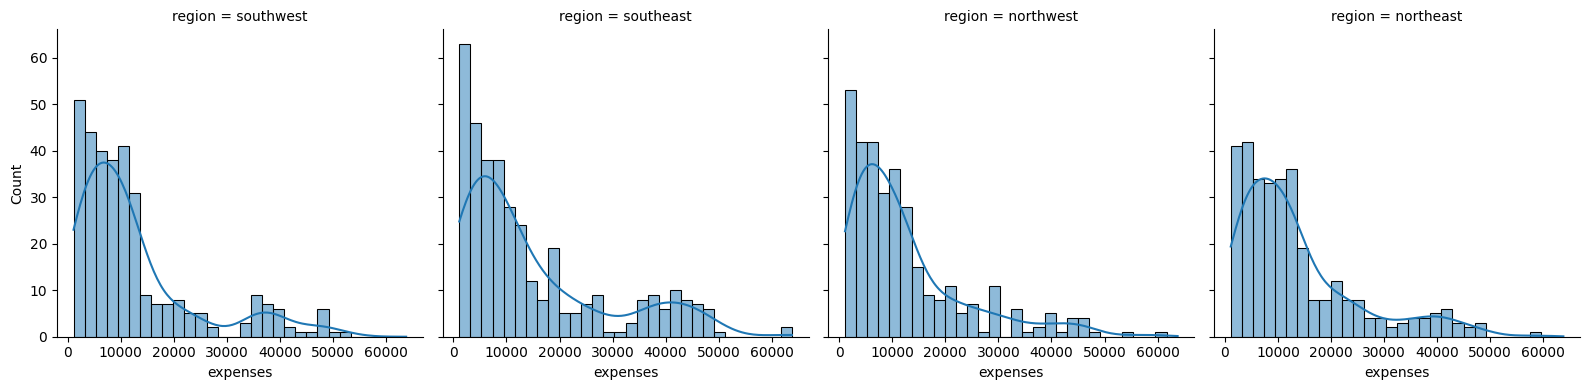

In [29]:
features = ['sex', 'children', 'region']

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for i, col in enumerate(features):
    sns.histplot(data=df, x='expenses', hue=col, kde=True, ax=axes[i])
    axes[i].set_title(f'Расходы по {col}')

plt.tight_layout()
plt.show()
sns.displot(data=df, x='expenses', col='region', kde=True, height=4, aspect=1)

*После интересного наблюдения с smokers хочется посмотреть и на другие графики. Я увидел, что expenses вообще не зависит от region, поэтому его можно смело удалить!*
***После теста я закомментил этот блок, потому что всё-таки regions немного поднял точность модели.***

In [30]:
#df.drop(columns=['region'], inplace=True)
# В последствие я потестил, раскомментив строку.
# без regions: R-squared = 0.8672
# с regions: R-squared = 0.8687

*Перед тем, как построить матрицу корелляций, надо закодировать значения, тк строки она не сможет распознать.*

In [31]:
df_encoded = df.copy()

df_encoded = pd.get_dummies(data=df_encoded, drop_first=True)
df_encoded.head()

,age,bmi,children,expenses,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,16884.92,False,True,False,False,True
1,18,33.8,1,1725.55,True,False,False,True,False
2,28,33.0,3,4449.46,True,False,False,True,False
3,33,22.7,0,21984.47,True,False,True,False,False
4,32,28.9,0,3866.86,True,False,True,False,False


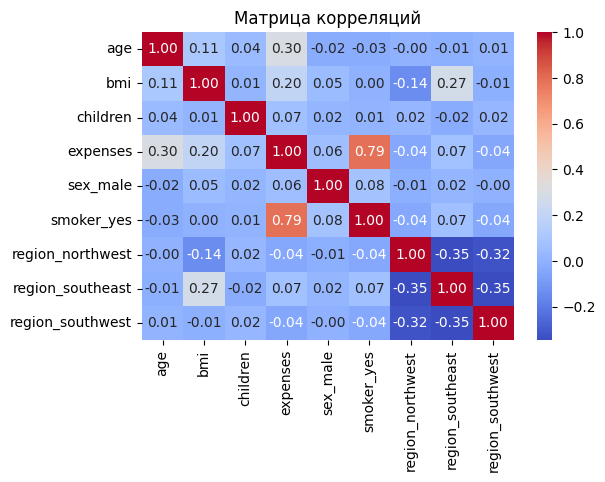

In [32]:
plt.figure(figsize=(6, 4))

numeric_df = df_encoded.select_dtypes(include=['int64', 'float64','bool'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

### **Выводы по EDA**
1. Expenses скошен вправо, так как в основном люди с хорошим здоровьем получают достаточно дешевую страховку. люди же с серьёзными проблемами сильно скашивают гистограмму.
2. В основном, корелляции очень незначительные, но они хоть какие-то. Regions мы вообще выкинули, потому что от региона совершенно не зависел expenses.
3. Самые сильные корелляции с expenses - у smoker, bmi и age
4. Корреляция целевого признака с children и sex очень низкая, но она всё же есть 

**Как я предобрабатывал данные?**

***проверил на пропуски, закодировал категориальные переменные через get_dummies***


## **3. Feature Engineering**

Мы уже удалили region, потому что он почти никак не влиял на expenses. Я решил добавить дополнительные признаки bmi_smoker и is_obese, потому что логично предположить, что курящий человек с ожирением гораздо менее вероятно получит дешёвую страховку, а ИМТ нам гораздо интереснее, если он выше 30, то есть у человека ожирение.

Также я сделал PolynomialFeatures, потому что линейная модель может не видеть нелинейные зависимости. в будущем можно проверить модель с ними и без, чтобы проверить эффективность.

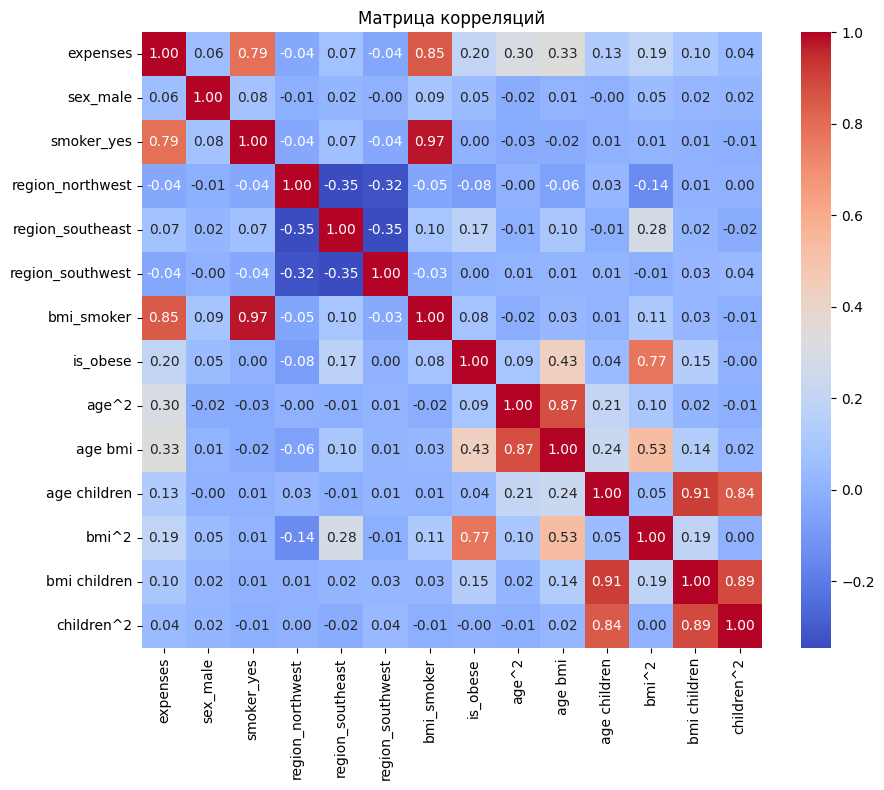

In [33]:
df_fe = df_encoded.copy()
df_fe['bmi_smoker'] = df_fe['bmi'] * df_fe['smoker_yes']
df_fe['is_obese'] = (df_fe['bmi'] >= 30).astype(int)

features_to_poly = ['age', 'bmi', 'children']

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_array = poly.fit_transform(df_fe[features_to_poly])
poly_feature_names = poly.get_feature_names_out(features_to_poly)
df_poly = pd.DataFrame(poly_array, columns=poly_feature_names)
df_fe = pd.concat([df_fe, df_poly], axis=1)
df_fe.drop(columns=features_to_poly, inplace=True)

plt.figure(figsize=(10, 8))

numeric_df = df_fe.select_dtypes(include=['int64', 'float64','bool'])

corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Матрица корреляций')
plt.show()

**Как вы работали с признаками?**

*сгенерировал новые на основе логики, добавил полиномиальные*

**Какие признаки добавили/изменили и почему?**

*Я решил добавить дополнительные признаки bmi_smoker и is_obese, потому что логично предположить, что курящий человек с ожирением гораздо менее вероятно получит дешёвую страховку, а ИМТ нам гораздо интереснее, если он выше 30, то есть у человека ожирение.*

**Какие удалили и почему?** 

*Я пробовал удалять region и признаки с низкой корреляцией, но это ухудшило модель, поэтому решил оставить всё.*

# **4. Разделение выборки**

разделяем выборку на тестовую и тренировочную.

In [34]:
X = df_fe.drop(columns=['expenses'])
y = df_fe['expenses']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)


Деревья работают и без скейлера. по факту нам не принципиально, будет ли в дереве разделение на больше/меньше 1000 или 1, потому что отскейлив всю выборку мы получим те же самые ответы на каждом разделении деревом.

НО я оставил скейлер, чтобы использовать его для регрессии. В дереве от этого ничего не изменится, а для регрессии масштабирование очень важно.

данные я разделил на 80% train 20% test

# **5. Обучение моделей**

При помощи GridSearchCV можно получить результаты всех моделей в красивой табличке.

In [35]:
alpha_array = [0.01, 0.1, 1.0, 10.0, 100.0]
# Выполняется минуту. нужно, чтобы красиво визуализировать
# график зависимости времени обучения от alpha.
# alpha_array = np.linspace(0.01, 100.0, 1000)

param_grid = [
    {"estimator": [LinearRegression()]},
    {"estimator": [Ridge()], "estimator__alpha": alpha_array},
    {"estimator": [Lasso()], "estimator__alpha": alpha_array}
]

scoring = ['r2', 'neg_mean_squared_error', 'neg_root_mean_squared_error']

pipe = Pipeline([("estimator", LinearRegression())]) # estimator здесь перезапишется при помощи grid, он ни на что не влияет.

grid = GridSearchCV(estimator = pipe,
                     param_grid=param_grid,
                     scoring = scoring,
                     refit='r2'
                     )

grid.fit(X_train_scaled, y_train)

resultsDf = pd.DataFrame(grid.cv_results_)

columns_to_show = [
    "param_estimator", 
    "param_estimator__alpha", 
    "mean_fit_time", 
    "mean_test_r2", 
    "mean_test_neg_root_mean_squared_error"
]

comparison_table = resultsDf[columns_to_show].copy()
display(comparison_table)
display(grid.best_params_)

,param_estimator,param_estimator__alpha,mean_fit_time,mean_test_r2,mean_test_neg_root_mean_squared_error
0,LinearRegression(),NaN,0.005378,0.835509,-4788.268154
1,Ridge(),0.01,0.003918,0.835509,-4788.270159
2,Ridge(),0.10,0.003456,0.835509,-4788.313281
3,Ridge(),1.00,0.003458,0.835363,-4790.952106
4,Ridge(),10.00,0.003036,0.828334,-4898.960384
5,Ridge(),100.00,0.004000,0.794748,-5378.216385
6,Lasso(),0.01,0.007898,0.835509,-4788.263070
7,Lasso(),0.10,0.006822,0.835512,-4788.217500
8,Lasso(),1.00,0.006137,0.835540,-4787.780326
9,Lasso(),10.00,0.004663,0.835701,-4785.204371


{'estimator': Lasso(), 'estimator__alpha': 10.0}

Обычно используют 5 или 10 фолдов. Как правило, такое количество даёт хорошее соотношение между скокростью и надежностью. Я использовал дефолтное значение (5)

**Как делить выборку, если не использовать кросс-валидацию?**

В этом случае данные делятся на Train , Validation и Test. Если делить только на две, есть риск подстроиться под тест в процессе выбора лучшей модели.

# Проверка качества моделей

In [36]:
y_pred = grid.predict(X_test_scaled)

final_r2 = r2_score(y_test, y_pred)
final_rmse = root_mean_squared_error(y_test, y_pred)
final_mse = mean_squared_error(y_test, y_pred)

y_pred_lasso = grid.predict(X_train_scaled)
print(f"Train R-squared: {r2_score(y_train, y_pred_lasso):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_lasso):.4f}")
print(f"Train RMSE: {root_mean_squared_error(y_train, y_pred_lasso):.4f}")

print(f"Final Test R-squared: {final_r2:.4f}")
print(f"Final Test MSE: {final_mse:.2f}")
print(f"Final Test RMSE: {final_rmse:.2f}")


Train R-squared: 0.8433
Train MSE: 22611538.5820
Train RMSE: 4755.1592
Final Test R-squared: 0.8690
Final Test MSE: 20340022.66
Final Test RMSE: 4509.99


In [37]:
depth = 5

start_tree = time.time()
tree_model = DecisionTreeRegressor(max_depth=depth, random_state=42)
tree_model.fit(X_train_scaled, y_train)
end_tree = time.time() - start_tree

start_rf = time.time()
rf_model = RandomForestRegressor(max_depth=depth, n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)
end_rf = time.time() - start_rf

dummy_model = DummyRegressor(strategy='mean')
dummy_model.fit(X_train_scaled, y_train)
y_pred_dummy = dummy_model.predict(X_test_scaled)

print(f"Время обучения Decision Tree: {end_tree:.4f} с")
print(f"Время обучения Random Forest: {end_rf:.4f} с")

Время обучения Decision Tree: 0.0099 с
Время обучения Random Forest: 0.3882 с


Одиночное дерево обучилось за сотую долю секунды, а рандомный лес учился в 60 раз дольше при n_estimators=100. Это связано с тем, что RandomForest строит 100 деревьев на своих подвыборках. Исправить ситуацию можно n_jobs=-1, которая будет многопоточно обучать деревья. Это приблизит скорость к обучению одного дерева, но (почти) одинаковой скорость будет только если количество потоков больше или равно n_estimators

In [38]:
y_pred_tree = tree_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)

print(f"Dummy R2: {r2_score(y_test, y_pred_dummy):.4f}")
print(f"Lasso R2: {final_r2:.4f}") 
print(f"Tree R2: {r2_score(y_test, y_pred_tree):.4f}")
print(f"Random Forest R2: {r2_score(y_test, y_pred_rf):.4f}")

Dummy R2: -0.0009
Lasso R2: 0.8690
Tree R2: 0.8450
Random Forest R2: 0.8734


Метрики: Я использовал RMSE, потому что она измеряется в долларах, что даёт наглядное понимание ошибок модели и сильнее штрафует за большие отклонения. R² нужен для понимания процента объясненной дисперсии.

Где считали: Метрики считались на тестовой выборке, которую модель не видела.

Кто лучше: Как и ожидалось, самые худшие результаты - у одиночного дерева (84.5%), лучше - у регрессии с лассо регуляризацией (86.90%), а самые лучшие - у рандомного леса (87.34%). Такие результаты обусловлены склонностью обычных дереьев к переобучению, отсутствием прунинга и тем, как хорошо работают ансамбли.

Насколько хорошие результаты: По сравнению с линейной регрессией мы улучшили результаты почти на 3%, что в целом очень неплохо, тем более на данных страховки, которые по определнию немного рандомные

In [39]:
models_data = {
    'Model': ['Lasso Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [
        r2_score(y_test, y_pred), 
        r2_score(y_test, y_pred_tree), 
        r2_score(y_test, y_pred_rf)
    ],
    'RMSE ($)': [
        root_mean_squared_error(y_test, y_pred),
        root_mean_squared_error(y_test, y_pred_tree),
        root_mean_squared_error(y_test, y_pred_rf)
    ],
    'Training Time (s)': [
        grid.cv_results_['mean_fit_time'][grid.best_index_],
        end_tree,
        end_rf
    ]
}

comparison_df = pd.DataFrame(models_data)
comparison_df = comparison_df.sort_values(by='R2 Score', ascending=False)

display(comparison_df.style.highlight_max(subset=['R2 Score'], color='green')
                         .highlight_min(subset=['RMSE ($)'], color='green'))

,Model,R2 Score,RMSE ($),Training Time (s)
2,Random Forest,0.873440,4432.644711,0.388196
0,Lasso Regression,0.868984,4509.991426,0.004663
1,Decision Tree,0.845001,4905.451968,0.009862


P.S. на самом деле лассо регрессия, вероятно, справилась бы даже хуже обычного дерева, если бы я вырезал feature engineering. во время feature engineering'а пару процентов R2 я смог получить при помощи создания фич по типу bmi_smoker. Без них лассо регрессия была бы намного слабее даже обычного дерева. А вот деревья даже без feature engineering'а выдали бы такие же результаты, это ещё один их плюс - не надо работать над фичами.

А рандомный лес справился лучше потому что зависимость страховки от BMI не линейная. Деревья с таким умеют работать, а ЛИНЕЙНАЯ регрессия - нет.